In [1]:
# Theoretical and Real AVO analysis using raw seismic data from KOPRI
# Zachary Katz
# 27 November 2025

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from obspy.io.segy.core import _read_segy
import os
import pandas as pd

############
geometry_path = './_data/KPDC_David_Seismic_2022/RAW/21YY-Geometry.csv' 
sgy_file = './_data/KPDC_David_Seismic_2022/RAW/21YY'
############

sgy_path = sgy_file + '.sgy'
fldr_number = 2  # Field record number

def segyload_obspy(sgy_path, fldr_number=1):
    # Load entire SEG-Y file
    st = _read_segy(sgy_path, unpack_trace_headers=True)

    # Sampling values
    dt = st[0].stats.delta          # seconds
    ns = st[0].stats.npts
    time = np.arange(ns) * dt       # seconds

    # Select traces based on Field Record Number (fldr)
    selected_traces = []
    coords = {'source_x': [], 'source_y': [], 'group_x': [], 'group_y': []}
    for tr in st:
        hdr = tr.stats.segy.trace_header
        if hdr.original_field_record_number == fldr_number:
            selected_traces.append(tr.data)
            coords['source_x'].append(hdr.source_coordinate_x)
            coords['source_y'].append(hdr.source_coordinate_y)
            coords['group_x'].append(hdr.group_coordinate_x)
            coords['group_y'].append(hdr.group_coordinate_y)

    if len(selected_traces) == 0:
        raise ValueError(f"No traces found for fldr={fldr_number}")

    data = np.stack(selected_traces)
    n_traces = data.shape[0]
    

    # Percentile clipping
    #lower_clip = np.percentile(data, 0.05)
    #upper_clip = np.percentile(data, 99.95)
    #data_clipped = np.clip(data, lower_clip, upper_clip)
    data_clipped = data

    # Transpose to (ns, n_traces) like segyio version
    data_clipped = data_clipped.T

    return data_clipped, time, n_traces, coords
    
data_clipped, time, n_traces, coords = segyload_obspy(sgy_path, fldr_number)

In [61]:
geometry = pd.read_csv(geometry_path)
subset_geometry = geometry[geometry["SHOT_POINT"] == fldr_number].reset_index(drop=True)
subset_geometry

,CMP,SHOT_POINT,CHANNEL,XSHOT,YSHOT,XREC,YREC,X_MIDPOINT,Y_MIDPOINT,CMP_XCENTER,CMP_YCENTER
0,12,2,1,662573,-1446963,662543,-1446781,662558.0,-1446872.0,662555.646,-1446869.136
1,13,2,2,662573,-1446963,662545,-1446796,662559.0,-1446879.5,662556.911,-1446876.559
2,14,2,3,662573,-1446963,662548,-1446811,662560.5,-1446887.0,662558.175,-1446883.983
3,15,2,4,662573,-1446963,662550,-1446826,662561.5,-1446894.5,662559.440,-1446891.406
4,16,2,5,662573,-1446963,662553,-1446841,662563.0,-1446902.0,662560.704,-1446898.829
...,...,...,...,...,...,...,...,...,...,...,...
91,103,2,92,662573,-1446963,662773,-1448131,662673.0,-1447547.0,662670.706,-1447544.637
92,104,2,93,662573,-1446963,662776,-1448146,662674.5,-1447554.5,662671.971,-1447552.060
93,105,2,94,662573,-1446963,662778,-1448161,662675.5,-1447562.0,662673.235,-1447559.483
94,106,2,95,662573,-1446963,662781,-1448176,662677.0,-1447569.5,662674.500,-1447566.906


96 96


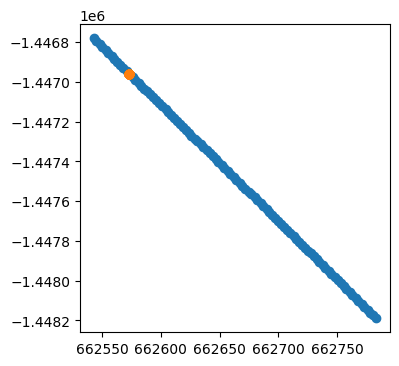

In [62]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(subset_geometry['XREC'], subset_geometry['YREC'])
ax.scatter(subset_geometry['XSHOT'], subset_geometry['YSHOT'])
print(len(subset_geometry['XSHOT']), len(data_clipped[0]))
assert len(subset_geometry['XSHOT']) == len(data_clipped[0]), "Incorrect length of shot data vs geometry file"


In [63]:
z = 2250 # Assume constant depth
dist = np.array([np.sqrt((subset_geometry['XSHOT'][i]-subset_geometry['XREC'][i])**2 + (subset_geometry['YSHOT'][i]-subset_geometry['YREC'][i])**2 ) for i in range(len(subset_geometry['XSHOT']))])
offset_angle = np.rad2deg(np.arctan2(dist, z))
offset_angle


array([ 4.68665179,  4.30386626,  3.91654088,  3.53301384,  3.14501083,
        2.76087898,  2.3974318 ,  2.01282314,  1.62393127,  1.23897705,
        0.84986679,  0.46117702,  0.10185906,  0.2903408 ,  0.67418499,
        1.06362353,  1.44827776,  1.83742686,  2.19687502,  2.58564652,
        2.96974534,  3.3579846 ,  3.74154623,  4.10416955,  4.49142254,
        4.87386756,  5.26025606,  5.64181373,  6.02720513,  6.3829559 ,
        6.76726356,  7.14666469,  7.5297179 ,  7.90783221,  8.28950358,
        8.64167446,  9.02189465,  9.39710039,  9.77569551, 10.15344089,
       10.52609674, 10.87784444, 11.2487265 , 11.62281912, 11.9917636 ,
       12.36383253, 12.7307311 , 13.07686333, 13.4416787 , 13.80946206,
       14.17203059, 14.53748619, 14.90174375, 15.2373854 , 15.59925877,
       15.95586011, 16.31518029, 16.66922081, 17.0259043 , 17.35444093,
       17.70850009, 18.05726679, 18.40853787, 18.75451666, 19.10292936,
       19.42373194, 19.76931815, 20.11341728, 20.45221794, 20.79

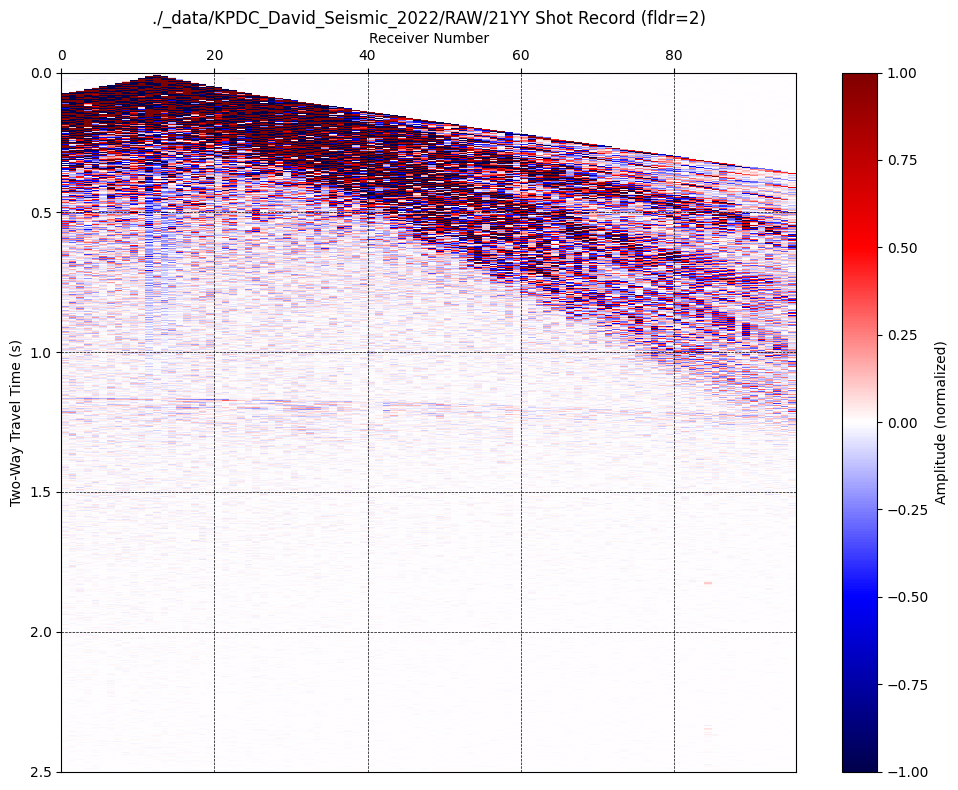

In [64]:
# Plot variable density image
fig, ax = plt.subplots(figsize=(10, 8))
extent = [0, n_traces, time[-1], time[0]]
im = ax.imshow(data_clipped,
               cmap='seismic',
               interpolation='none', # 'gaussian' to get image that looks like Ju's
               aspect='auto',
               extent=extent,
               vmin=-1, vmax=1)

# 범위 제한
ax.set_xlim(0, 96)         # x축: trace 1번 ~ 96번
ax.set_ylim(2.5, 0)        # y축: 0 ~ 2.5초

# 수신기 점선 (20개 간격)
recive_grid = np.arange(0, 96, 20)
for t in recive_grid:
    ax.axvline(x=t, color='black', linestyle='--', linewidth=0.5)

# 시간축 점선 (0.1초 간격)
time_grid = np.arange(0, 2.5, 0.5)
for t in time_grid:
    ax.axhline(y=t, color='black', linestyle='--', linewidth=0.5)

# Labeling
ax.set_title(f"{sgy_file} Shot Record (fldr={fldr_number})")
ax.set_xlabel("Receiver Number")
ax.set_ylabel("Two-Way Travel Time (s)")

# x축 라벨과 눈금을 상단으로
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Amplitude (normalized)')

plt.tight_layout()
plt.show()

# export the figure
#fig.savefig(f"{figures_dir}/{sgy_file}_raw_data_gather_fldr{fldr_number}.pdf",
#            dpi=300, bbox_inches='tight')
#plt.close(fig)

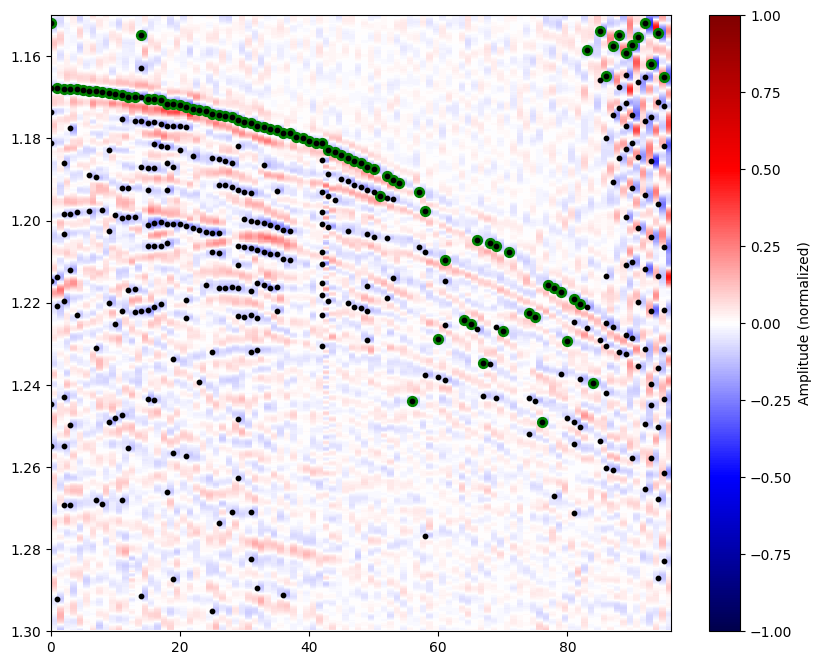

In [109]:
# For trace in the 96 traces, get the amplitude of the first reflection
from scipy.signal import find_peaks

fig, ax = plt.subplots(figsize=(10, 8))
st_time = 1.15
et_time = 1.3

# slice indices
i1 = np.searchsorted(time, st_time)
i2 = np.searchsorted(time, et_time)

data_win = data_clipped[i1:i2, :]
time_win = time[i1:i2]

extent = [0, n_traces, time_win[-1], time_win[0]]

im = ax.imshow(
    data_win,
    cmap='seismic',
    interpolation='none',
    aspect='auto',
    extent=extent,
    vmin=-1, vmax=1
)

ax.set_xlim(0, n_traces)       # traces 0..N
ax.set_ylim(et_time, st_time)  # flip time axis (deeper at bottom)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Amplitude (normalized)')

peak_indices_per_trace = [] # Save all peaks
peak_props_per_trace = [] # Save all peak properties
first_peak_time = np.full(data_clipped.shape[1], np.nan) # Save first peak
first_peak_amp = np.full(data_clipped.shape[1], np.nan)   # Save first peak amplitude

for trace_idx in range(data_clipped.shape[1]):
    trace = data_win[:, trace_idx]
    trace = -trace

    # Find peaks — add parameters as needed (height, distance, prominence…)
    peaks, props = find_peaks(trace, prominence=0.1, distance=10, height=0.1)

    if len(peaks) > 0:
        first_idx = peaks[0]          # earliest (shallowest) peak
        first_peak_amp[trace_idx] = -trace[first_idx] # Looking at minima still
        first_peak_time[trace_idx] = time_win[first_idx]

    peak_indices_per_trace.append(peaks)
    peak_props_per_trace.append(props)

#print(first_peak_time)
#print(first_peak_amp)

peak_times = [time[peaks] for peaks in peak_indices_per_trace]
peak_amps = [-data_clipped[peaks, tr] for tr, peaks in enumerate(peak_indices_per_trace)]

for tr, peaks in enumerate(peak_indices_per_trace):
    ax.scatter([tr]*len(peaks), time_win[peaks],color='black', s=10,zorder=10)

ax.scatter(np.arange(data_clipped.shape[1]),first_peak_time, color='green',s=50)
#print(first_peak_amp)



In [110]:
# Make theoretical AVO curves
def Aki_Richards_ZoeppritzApprox(angles, p1, p2, s1, s2, rho1, rho2):
    thetas = np.deg2rad(angles)
    p = (p1 + p2) / 2
    delta_p = p2 - p1
    s = (s1 + s2) / 2
    delta_s = s2 - s1
    rho = (rho1 + rho2) / 2
    delta_rho = rho2 - rho1

    term1 = 0.5 * ( 1 + np.tan(thetas)*np.tan(thetas)) * delta_p / p
    term2 = (4 * (s*s) / (p * p) * np.sin(thetas) * np.sin(thetas) * delta_s / s)
    term3 = 0.5 * ( 1 -4 * (s*s) / (p * p) * np.sin(thetas) * np.sin(thetas))* delta_rho / rho

    return term1 - term2 + term3

def Shuey_ZoeppritzApprox(angles, p1, p2, s1, s2, rho1, rho2):
    
    thetas = np.deg2rad(angles)
    p = (p1 + p2) / 2
    delta_p = p2 - p1
    s = (s1 + s2) / 2
    delta_s = s2 - s1
    rho = (rho1 + rho2) / 2
    delta_rho = rho2 - rho1
    
    R0 = 0.5 * (delta_p / p + delta_rho / rho)
    k = (s / p) ** 2
    G = 0.5 * (delta_p / p) - 2.0 * k * (delta_rho / rho + 2.0 * delta_s / s)
    F = 0.5 * (delta_p / p)
    R = R0 + G * np.sin(thetas)**2 + F * (np.tan(thetas)**2 - np.sin(thetas)**2)
    return R

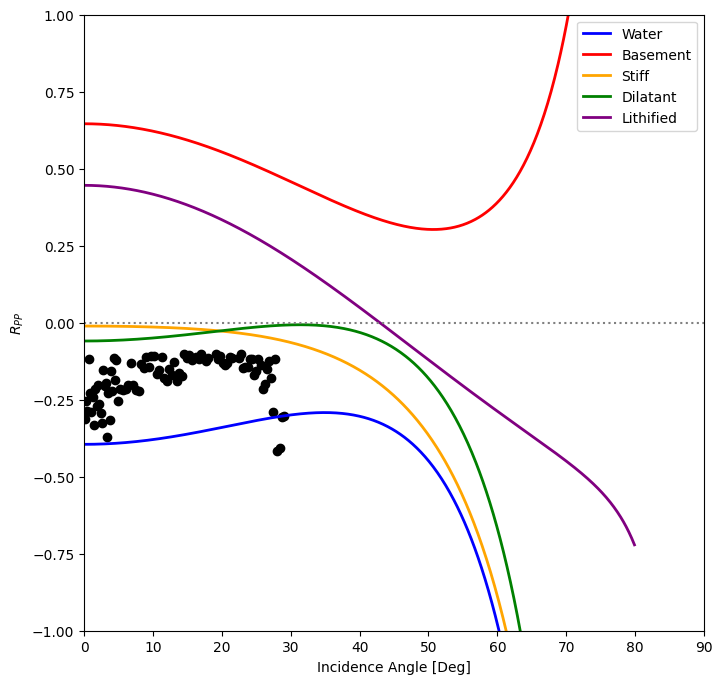

In [112]:
angles = np.arange(0, 80, 0.1)

# Ice
alpha_Ice = 3810
beta_Ice = 1860
rho_Ice =  920

materials = {
    "Water": {
        "alpha": 1500,
        "beta": 0,
        "rho": 997,
    },
    "Basement": {
        "alpha": 5200,
        "beta": 2800,
        "rho": 2700,
    },
    "Stiff": {
        "alpha": 1800,
        "beta": 1000,
        "rho": 1900,
    },
    "Dilatant": {
        "alpha": 1700,
        "beta": 200,
        "rho": 1800,
    },
    "Lithified": {
        "alpha": 3750,
        "beta": 2450,
        "rho": 2450,
    },
}

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['blue', 'red', 'orange','green', 'purple']
for color, (name, props) in zip(colors, materials.items()):
    #R = Aki_Richards_ZoeppritzApprox(angles, alpha_Ice, props['alpha'], beta_Ice, props['beta'], rho_Ice, props['rho'])
    R = Shuey_ZoeppritzApprox(angles, alpha_Ice, props['alpha'], beta_Ice, props['beta'], rho_Ice, props['rho'])
    ax.plot(angles, R, color=color, label=name, linewidth=2)
    ax.legend()
ax.set_ylim(-1,1)
ax.set_xlim(0,90)
ax.axhline(0, color='gray', linestyle=':')
ax.set_ylabel(r'$R_{PP}$')
ax.set_xlabel('Incidence Angle [Deg]')

ax.scatter(offset_angle, first_peak_amp, color='k')


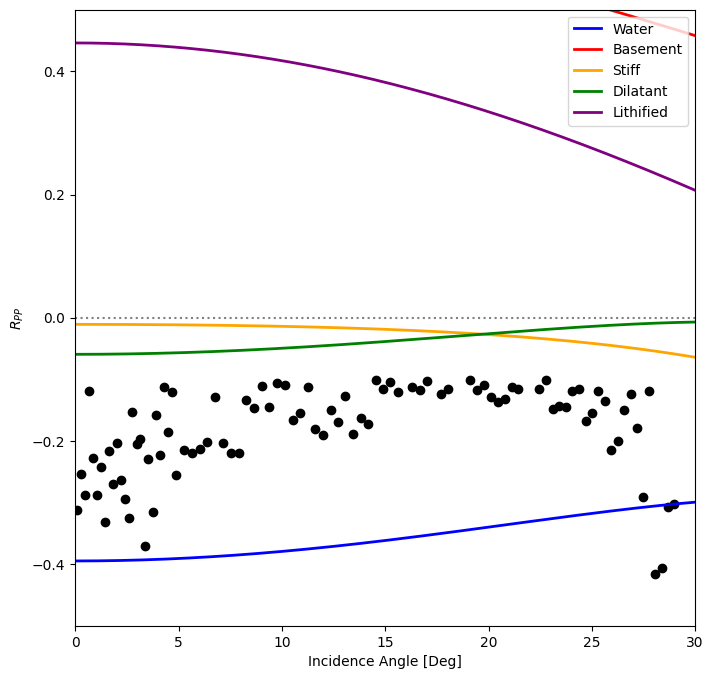

In [113]:
# Zoom verison
fig, ax = plt.subplots(figsize=(8, 8))
colors = ['blue', 'red', 'orange','green', 'purple']
for color, (name, props) in zip(colors, materials.items()):
    #R = Aki_Richards_ZoeppritzApprox(angles, alpha_Ice, props['alpha'], beta_Ice, props['beta'], rho_Ice, props['rho'])
    R = Shuey_ZoeppritzApprox(angles, alpha_Ice, props['alpha'], beta_Ice, props['beta'], rho_Ice, props['rho'])
    ax.plot(angles, R, color=color, label=name, linewidth=2)
    ax.legend()
ax.set_ylim(-0.5,0.5)
ax.set_xlim(0,30)
ax.axhline(0, color='gray', linestyle=':')
ax.set_ylabel(r'$R_{PP}$')
ax.set_xlabel('Incidence Angle [Deg]')

ax.scatter(offset_angle, first_peak_amp, color='k')
